# Sentiment Analysis Project

### Library

In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
from indo_normalizer import Normalizer
from langdetect import detect
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Get the Data

In [2]:
df = pd.read_csv("dataset/instagram_reviews.csv")
df = df[['content', 'score']]
df.head()

,content,score
0,"instagram jelek ajg, lu kalo mau pembersihan c...",1
1,sangat membantu,5
2,tolong itu ilangin fitur foto yg sekali liat bg,4
3,"baguss bangett,dapet temen banyakk jugaa di sinii",5
4,gk bisa login padahal di IG web bisa katanya k...,1


### Preprocessing

In [3]:
# NLTK download
nltk.download('punkt')

# Stopwords
stop_factory = StopWordRemoverFactory()
stopwords = stop_factory.get_stop_words()

# Stemming
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

normalizer = Normalizer()

Korpus 'c:\Users\VivoBook\AppData\Local\Programs\Python\Python311\Lib\site-packages\indo_normalizer\corpus\common_words.txt' berhasil dimuat. (18122 kata)
Korpus 'c:\Users\VivoBook\AppData\Local\Programs\Python\Python311\Lib\site-packages\indo_normalizer\corpus\slangs.csv' berhasil dimuat. (1284 pasangan)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\VivoBook\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
def clean_text(text):
    # Case folding
    text = text.lower()
    # Remove number
    text = re.sub(r'\d+', '', text)
    # Remove emoji
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove white space
    text = text.strip()
    # Tokenization
    words = word_tokenize(text)
    
    clean_words = []
    for w in words:
        if w and w not in stopwords:
            try:
                lang = detect(w)
            except:
                lang = "id"
                
            if lang == "id":
                norm = normalizer.normalize_text(w)
                if isinstance(norm, (tuple, list)):
                    norm = norm[0]
                clean_words.append(stemmer.stem(str(norm)))
            else:
                clean_words.append(w)
                
    return " ".join(clean_words)

df['clean_content'] = df['content'].astype(str).apply(clean_text)

### Labelling the Data

In [5]:
def label_sentiment(score):
    if score <= 2:
        return -1
    elif score == 3:
        return 0
    else:
        return 1

df['sentiment'] = df['score'].apply(label_sentiment)

In [6]:
df.tail()

,content,score,clean_content,sentiment
9995,i like it,5,i like it,1
9996,oke lah,4,oke lah,1
9997,aplikasi keren,5,aplikasi keren,1
9998,"I Like This App, This App Is Not The Same As T...",5,i like this app this app is not the same as ti...,1
9999,minimal live Instagram ada fitur translate nya...,2,minimal live instagram fitur translate nya lah...,-1


### Training & Inference

In [7]:
def run_experiment(model_class, features, test_size=0.2):
    X = features.fit_transform(df['clean_content'])
    y = df['sentiment']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    model = model_class()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Classification report
    print(classification_report(y_test, y_pred))
    
    # Cross-validation
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print("Cross-validation scores:", scores)
    print("Mean accuracy:", scores.mean())
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 0, 1])
    disp.plot()
    
    return model, features

=== 1. SVM + TF-IDF + split 80/20 ===


c:\Users\VivoBook\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\VivoBook\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\VivoBook\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\VivoBook\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set t

              precision    recall  f1-score   support

          -1       1.00      0.99      0.99       649
           0       1.00      0.89      0.94        80
           1       0.99      1.00      0.99      1271

    accuracy                           0.99      2000
   macro avg       0.99      0.96      0.98      2000
weighted avg       0.99      0.99      0.99      2000



c:\Users\VivoBook\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\VivoBook\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Cross-validation scores: [0.9895 0.9915 0.99   0.9915 0.9905]
Mean accuracy: 0.9906
=== Inference with SVM + TF-IDF ===
Text: aplikasi ini jelek banget dan tidak berguna, bikin ribet -> Prediction: negative
Text: lumayan sih, kadang lancar kadang enggak -> Prediction: positive
Text: fiturnya bagus dan sangat membantu -> Prediction: positive


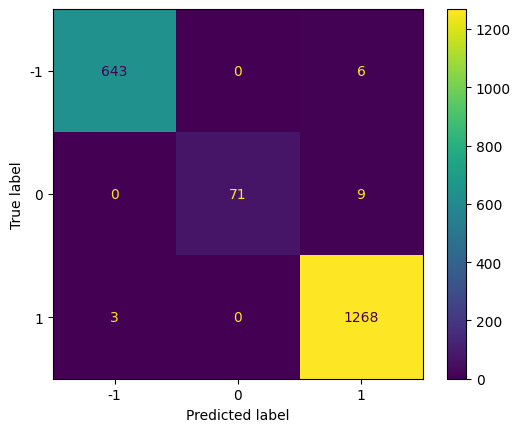

In [8]:
# 1. SVM + TF-IDF + split 80/20
print("=== 1. SVM + TF-IDF + split 80/20 ===")
svm_model, svm_vectorizer = run_experiment(LinearSVC, TfidfVectorizer(max_features=5000), test_size=0.2)

# Inference
sample_texts = [
    "aplikasi ini jelek banget dan tidak berguna, bikin ribet",
    "lumayan sih, kadang lancar kadang enggak",
    "fiturnya bagus dan sangat membantu"
]
sample_clean = [clean_text(t) for t in sample_texts]
label_map = {-1: "negative", 0: "neutral", 1: "positive"}

svm_sample_features = svm_vectorizer.transform(sample_clean)
svm_sample_preds = svm_model.predict(svm_sample_features)
print("=== Inference with SVM + TF-IDF ===")
for text, pred in zip(sample_texts, svm_sample_preds):
    print(f"Text: {text} -> Prediction: {label_map[pred]}")

=== 2. RF + TF-IDF + (70/30) ===
              precision    recall  f1-score   support

          -1       0.99      0.99      0.99       956
           0       1.00      0.89      0.94       134
           1       0.99      1.00      0.99      1910

    accuracy                           0.99      3000
   macro avg       0.99      0.96      0.97      3000
weighted avg       0.99      0.99      0.99      3000

Cross-validation scores: [0.9895 0.9915 0.99   0.9915 0.9905]
Mean accuracy: 0.9906
=== Inference with RF + TF-IDF ===
Text: aplikasi ini jelek banget dan tidak berguna, bikin ribet -> Prediction: negative
Text: lumayan sih, kadang lancar kadang enggak -> Prediction: positive
Text: fiturnya bagus dan sangat membantu -> Prediction: positive


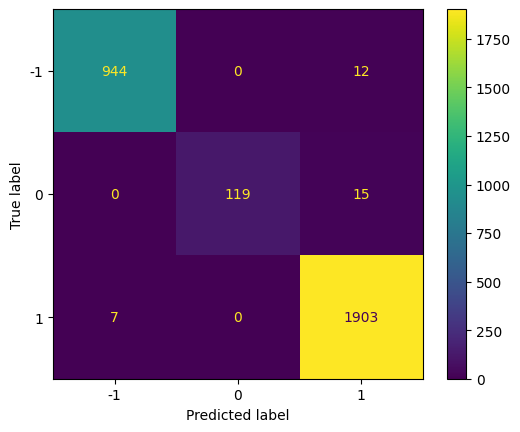

In [9]:
# 2. RF + TF-IDF + split 70/30
print("=== 2. RF + TF-IDF + (70/30) ===")
rf_model, rf_vectorizer = run_experiment(RandomForestClassifier, TfidfVectorizer(max_features=5000), test_size=0.3)

rf_sample_features = rf_vectorizer.transform(sample_clean)
rf_sample_preds = rf_model.predict(rf_sample_features)
print("=== Inference with RF + TF-IDF ===")
for text, pred in zip(sample_texts, rf_sample_preds):
    print(f"Text: {text} -> Prediction: {label_map[pred]}")

=== 3. RF + Word2Vec (80/20) ===
              precision    recall  f1-score   support

          -1       0.99      0.99      0.99       650
           0       0.90      1.00      0.95        90
           1       1.00      0.99      0.99      1260

    accuracy                           0.99      2000
   macro avg       0.96      0.99      0.98      2000
weighted avg       0.99      0.99      0.99      2000

Cross-validation scores: [0.9895 0.9915 0.99   0.9915 0.9905]
Mean accuracy: 0.9906
=== Inference with RF + Word2Vec ===
Text: aplikasi ini jelek banget dan tidak berguna, bikin ribet -> Prediction: positive
Text: lumayan sih, kadang lancar kadang enggak -> Prediction: positive
Text: fiturnya bagus dan sangat membantu -> Prediction: positive


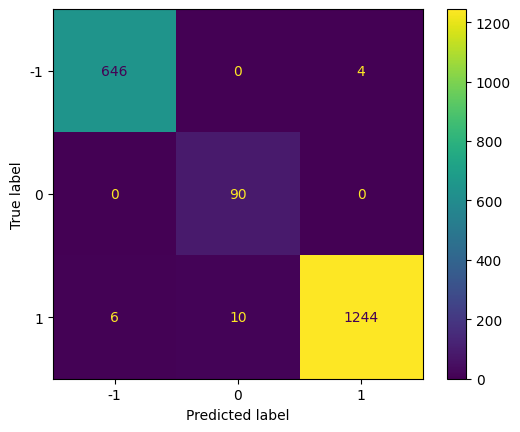

In [10]:
# 3. RF + Word2Vec + split 80/20
sentences = df['clean_content'].tolist()

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

def vectorize_text(words):
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X = np.array([vectorize_text(words) for words in df['clean_content']])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("=== 3. RF + Word2Vec (80/20) ===")
print(classification_report(y_test, y_pred))

# Cross-validation
scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
    
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 0, 1])
disp.plot()

w2v_sample_features = np.array([vectorize_text(words.split()) for words in sample_clean])
w2v_sample_preds = rf_model.predict(w2v_sample_features)
print("=== Inference with RF + Word2Vec ===")
for text, pred in zip(sample_texts, w2v_sample_preds):
    print(f"Text: {text} -> Prediction: {label_map[pred]}")